In [28]:
import sys
import os
sys.path.append(os.path.abspath("../src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from preprocessing import load_preprocess_data
from datetime import datetime
from classical_models import LogisticRegression, KNN, DecisionTree

In [29]:
def run_experiments(X_train, y_train, X_test, y_test):
    results = []
    models = [
        (LogisticRegression(), "Logistic Regression"),
        (KNN(k=5), "KNN"),
        (DecisionTree(max_depth=2), "Decision Tree")
    ]
    for model, name in models:
        model.fit(X_train, y_train)
        result = model.evaluate(X_test, y_test)
        results.append(result)
    return results

In [30]:
def print_results(results):
    print("\n===== MODEL COMPARISON =====\n")

    with open("../results/experiment_log.txt", "a") as f:

        f.write("\n============================\n")
        f.write(f"Experiment Date: {datetime.now()}\n")
        f.write("============================\n\n")

        for r in results:

            output = (
                f"Model: {r['model']}\n"
                f"Accuracy: {r['accuracy']:.4f}\n"
                f"Precision: {r['precision']:.4f}\n"
                f"Recall: {r['recall']:.4f}\n"
                f"F1 Score: {r['f1_score']:.4f}\n"
                f"Confusion Matrix:\n{r['confusion_matrix']}\n"
                f"----------------------------\n"
            )

            print(output)
            f.write(output)

In [31]:
def plot_model_comparison(results):

    models = [r['model'] for r in results]

    accuracy_scores = [r['accuracy'] for r in results]
    f1_scores = [r['f1_score'] for r in results]

    x = range(len(models))

    plt.figure(figsize=(10, 6))

    plt.bar(x, accuracy_scores, width=0.4, label='Accuracy')

    plt.bar(
        [i + 0.4 for i in x],
        f1_scores,
        width=0.4,
        label='F1 Score'
    )

    plt.xticks([i + 0.2 for i in x], models)

    plt.ylabel("Score")

    plt.title("Model Comparison")

    plt.legend()

    plt.savefig("../figures/model_comparison.png")

    plt.show()

In [32]:
def save_metrics_table(results):

    data = []

    for r in results:

        data.append({
            "Model": r['model'],
            "Accuracy": r['accuracy'],
            "Precision": r['precision'],
            "Recall": r['recall'],
            "F1 Score": r['f1_score']
        })

    df = pd.DataFrame(data)

    df.to_csv("../results/metrics_table.csv", index=False)

    print("metrics_table.csv saved successfully!")


===== MODEL COMPARISON =====

Model: Logistic Regression
Accuracy: 0.9735
Precision: 1.0000
Recall: 0.9167
F1 Score: 0.9565
Confusion Matrix:
[[33  0]
 [ 3 77]]
----------------------------

Model: KNN
Accuracy: 0.9646
Precision: 1.0000
Recall: 0.8889
F1 Score: 0.9412
Confusion Matrix:
[[32  0]
 [ 4 77]]
----------------------------

Model: Decision Tree
Accuracy: 0.9115
Precision: 0.8421
Recall: 0.8889
F1 Score: 0.8649
Confusion Matrix:
[[32  6]
 [ 4 71]]
----------------------------



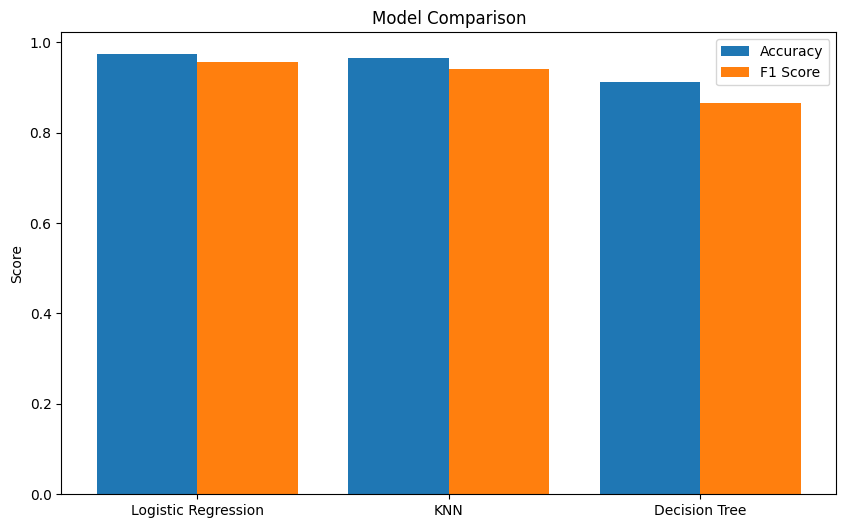

metrics_table.csv saved successfully!


In [33]:

X_train, y_train ,  X_test, y_test = load_preprocess_data("../data/data.csv")
results = run_experiments(X_train, y_train, X_test, y_test)
print_results(results)
plot_model_comparison(results)
save_metrics_table(results)

Model performance varied across random train-test splits, motivating the use of cross-validation for more robust evaluation.